# Ingeniería de variables — ¿qué le damos de comer a los árboles?

**Punto de partida.** El primer entrenamiento dejó un diagnóstico incómodo:

| modelo | ROC-AUC global | Recall @ FPR 5 % | Recall @ top-1 % **diario** |
|---|---|---|---|
| Regresión logística `t1` | 0.945 | 78.9 % | **4.1 %** |
| LightGBM `t1` | 0.901 | 27.2 % | **2.4 %** |

La métrica global es excelente y la diaria es un desastre. La explicación es que las dos miden
cosas distintas:

- **ROC-AUC global** mezcla todos los días del año, así que se lleva casi gratis la
  discriminación estacional: agosto arde, enero no.
- **Recall @ top-1 % diario** obliga a elegir las 307 celdas más peligrosas *de hoy*. La
  estacionalidad no ayuda, porque todas las celdas comparten el mismo día.

Operativamente solo importa la segunda: una brigada no necesita que le digan que en verano
hay más riesgo. Necesita saber **a qué monte ir esta mañana**.

**Objetivo de este cuaderno:** encontrar variables que discriminen *dentro del día*, y decidir
con datos cuáles merecen entrar al modelo.

**Muestra:** `data/processed/eda_sample_t1.parquet`, generada con
`python -m scripts.build_eda_sample --mode t1`. Contiene los 1.543 incendios de 2019-2022 y
una muestra 1:150 de días sin incendio.

> La prevalencia de la muestra **no** es la real (1:150 frente a 1:38.000). Sirve para estudiar
> relaciones entre variables, nunca para estimar rendimiento: para eso está
> `scripts/train_model.py`, que evalúa sobre el año completo.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

from src.features.derived import BASE_VARS, derived_columns  # noqa: E402

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_parquet(REPO / "data" / "processed" / "eda_sample_t1.parquet")
print(f"{len(df):,} filas | {int(df.target.sum()):,} incendios | {df.shape[1]} columnas")
print(f"particiones: {df.particion.value_counts().to_dict()}")
df.head(3)

232,644 filas | 1,543 incendios | 39 columnas
particiones: {'train': 126255, 'val': 106389}


,cell_id,fecha,target,tmax_vc,rhmin_vc,vmax_vc,prec_dia,prec_acum_7d,prec_acum_30d,tmax_media_7d,alerta_30_30,altitud_media,pendiente_media,orientacion_media,combustible_pct_forestal,combustible_clase,orientacion_clase,mes,dia_semana,es_finde,fecha_real,dia_anio_sin,dia_anio_cos,vpd,dias_sin_lluvia,nesterov,ratio_termico_eolico,tmax_vc_anom,rhmin_vc_anom,vmax_vc_anom,prec_acum_7d_anom,tmax_vc_z_dia,rhmin_vc_z_dia,vmax_vc_z_dia,prec_acum_7d_z_dia,vpd_x_forestal,seq_x_forestal,anio,particion
0,0,2019-02-22,0,12.326480,69.248619,29.558739,0.020272,40.097856,196.059738,13.634603,0.0,52.308704,11.918222,113.734360,7.407407,pastizal,este,2,3,0,2019-02-21,0.779913,0.625889,0.440681,2.0,145.906174,5.261552,-1.406954,-4.541592,2.801317,-31.307505,0.228482,2.907126,4.100222,2.409701,0.032643,0.148148,2019,train
1,1,2019-02-28,0,18.575413,55.771191,16.290716,0.002574,2.505127,177.261540,16.875723,0.0,17.898726,7.266884,73.014145,0.000000,matorral,este,2,2,0,2019-02-27,0.840248,0.542202,0.946433,8.0,939.100769,5.425862,4.618314,-18.019020,-10.466705,-68.900238,-0.268235,3.177471,2.473840,3.938360,0.000000,0.000000,2019,train
2,1,2019-08-19,0,21.257786,88.489799,29.297930,2.785712,10.104162,74.683431,20.485900,0.0,17.898726,7.266884,73.014145,0.000000,matorral,este,8,6,1,2019-08-18,-0.727701,-0.685894,0.290824,0.0,733.639343,7.038203,-0.191908,14.999922,8.033874,-7.959027,-1.988333,2.346122,2.479661,0.176157,0.000000,0.000000,2019,train


---
## 1. ¿De dónde sale realmente la señal?

Antes de inventar variables nuevas conviene medir cuánto aporta cada bloque de las que ya
tenemos. La prueba es directa: entrenar con **un solo grupo de variables cada vez** y ver el
ROC-AUC. Si el grupo de calendario por sí solo ya alcanza casi el resultado final, entonces lo
que tenemos es un modelo estacional disfrazado.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

GRUPOS = {
    "calendario":  ["mes", "dia_semana", "es_finde", "dia_anio_sin", "dia_anio_cos"],
    "meteo cruda": ["tmax_vc", "rhmin_vc", "vmax_vc", "prec_dia"],
    "memoria":     ["prec_acum_7d", "prec_acum_30d", "tmax_media_7d", "alerta_30_30"],
    "terreno":     ["altitud_media", "pendiente_media", "orientacion_media",
                    "combustible_pct_forestal"],
    "anomalias":   [c for c in df.columns if c.endswith("_anom")],
    "relativas":   [c for c in df.columns if c.endswith("_z_dia")],
    "fisicas":     ["vpd", "dias_sin_lluvia", "nesterov", "ratio_termico_eolico"],
}

tr, va = df[df.particion == "train"], df[df.particion == "val"]

def auc_grupo(cols):
    """ROC-AUC de una logistica entrenada solo con ese grupo de variables."""
    m = make_pipeline(StandardScaler(),
                      LogisticRegression(max_iter=2000, class_weight="balanced"))
    m.fit(tr[cols].fillna(0), tr.target)
    return roc_auc_score(va.target, m.predict_proba(va[cols].fillna(0))[:, 1])

res = pd.DataFrame(
    [{"grupo": g, "n_vars": len(c), "roc_auc": auc_grupo(c)} for g, c in GRUPOS.items()]
).sort_values("roc_auc", ascending=False)

todas = sorted({c for cols in GRUPOS.values() for c in cols})
res.loc[len(res)] = {"grupo": "TODAS JUNTAS", "n_vars": len(todas), "roc_auc": auc_grupo(todas)}
res.round(4)

,grupo,n_vars,roc_auc
2,memoria,4,0.9264
6,fisicas,4,0.9263
1,meteo cruda,4,0.9256
4,anomalias,4,0.8678
0,calendario,5,0.8568
3,terreno,4,0.6851
5,relativas,4,0.6849
7,TODAS JUNTAS,29,0.9270


**Cómo leerlo.** Compara cada grupo con `TODAS JUNTAS`. Si `calendario` en solitario se queda
cerca del total, confirma que el modelo vive de la estacionalidad y que el resto de variables
apenas añaden. Los grupos `anomalias` y `relativas` son los que hemos construido precisamente
para aportar señal *no* estacional: si tienen ROC bajo pero suman al combinarse, están
aportando algo ortogonal, que es lo que buscamos.

---
## 2. La prueba que de verdad importa: discriminación dentro del día

El ROC-AUC global premia acertar la estacionalidad. Para aislar la señal espacial calculamos el
**ROC-AUC dentro de cada día**: para cada jornada con algún incendio, ¿ordena la variable las
celdas que ardieron por encima de las que no?

Una variable puramente estacional dará 0.5 aquí — es constante en toda Galicia ese día — por muy
bien que puntúe en la métrica global. Es el filtro que separa lo decorativo de lo operativo.

In [3]:
def auc_intra_dia(col, datos, min_pos=1):
    """ROC-AUC medio calculado dentro de cada dia, ponderado por numero de incendios."""
    aucs, pesos = [], []
    for _, g in datos.groupby("fecha_real"):
        n_pos = int(g.target.sum())
        if n_pos < min_pos or n_pos == len(g):
            continue
        x = g[col].to_numpy()
        if np.all(np.isnan(x)) or np.nanstd(x) == 0:
            continue
        aucs.append(roc_auc_score(g.target, np.nan_to_num(x, nan=np.nanmedian(x))))
        pesos.append(n_pos)
    if not aucs:
        return np.nan, 0
    return float(np.average(aucs, weights=pesos)), len(aucs)

candidatas = sorted({c for cols in GRUPOS.values() for c in cols})
filas = []
for c in candidatas:
    glob = roc_auc_score(va.target, np.nan_to_num(va[c], nan=0.0))
    intra, n_dias = auc_intra_dia(c, va)
    filas.append({"variable": c,
                  "auc_global": max(glob, 1 - glob),
                  "auc_intra_dia": max(intra, 1 - intra) if intra == intra else np.nan,
                  "n_dias": n_dias})

comp = pd.DataFrame(filas)
comp["ganancia_espacial"] = comp.auc_intra_dia - 0.5
comp.sort_values("auc_intra_dia", ascending=False).round(4)

,variable,auc_global,auc_intra_dia,n_dias,ganancia_espacial
20,rhmin_vc_z_dia,0.7494,0.7202,74,0.2202
18,rhmin_vc,0.9110,0.7202,74,0.2202
9,nesterov,0.9056,0.7023,69,0.2023
28,vpd,0.9164,0.6593,74,0.1593
11,pendiente_media,0.6457,0.6485,74,0.1485
1,altitud_media,0.6363,0.6437,74,0.1437
0,alerta_30_30,0.7620,0.6302,30,0.1302
17,ratio_termico_eolico,0.8796,0.6294,74,0.1294
19,rhmin_vc_anom,0.8307,0.6294,74,0.1294
2,combustible_pct_forestal,0.6041,0.6116,74,0.1116


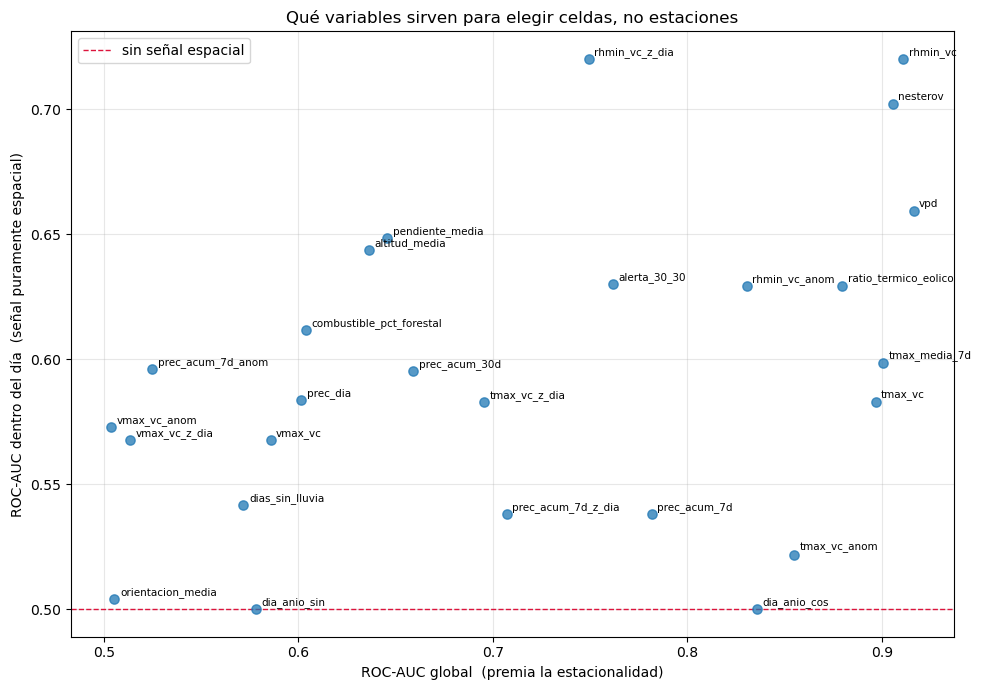

In [4]:
# Global frente a intra-dia. Las variables utiles operativamente son las que se separan
# del eje horizontal 0.5, no las que se van a la derecha.
fig, ax = plt.subplots(figsize=(10, 7))
ax.axhline(0.5, color="crimson", lw=1, ls="--", label="sin señal espacial")
ax.scatter(comp.auc_global, comp.auc_intra_dia, s=45, alpha=0.75, zorder=3)
for _, r in comp.iterrows():
    if r.auc_intra_dia == r.auc_intra_dia:
        ax.annotate(r.variable, (r.auc_global, r.auc_intra_dia),
                    fontsize=7.5, xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("ROC-AUC global  (premia la estacionalidad)")
ax.set_ylabel("ROC-AUC dentro del día  (señal puramente espacial)")
ax.set_title("Qué variables sirven para elegir celdas, no estaciones")
ax.legend()
plt.tight_layout()

---
## 3. Redundancia: ¿cuáles sobran?

Meter dos variables que dicen lo mismo no añade información y sí reparte la importancia entre
ambas, dificultando la interpretación. `prec_acum_7d` y `prec_acum_30d` o `tmax_vc` y
`tmax_media_7d` son sospechosas por construcción.

Pares con |rho| > 0.8 — candidatos a eliminar uno de los dos:
tmax_vc          tmax_media_7d           0.902
vpd              rhmin_vc                0.880
                 tmax_vc                 0.872
vmax_vc_anom     vmax_vc                 0.851
dias_sin_lluvia  prec_dia                0.844
tmax_vc          ratio_termico_eolico    0.823
rhmin_vc         rhmin_vc_anom           0.805


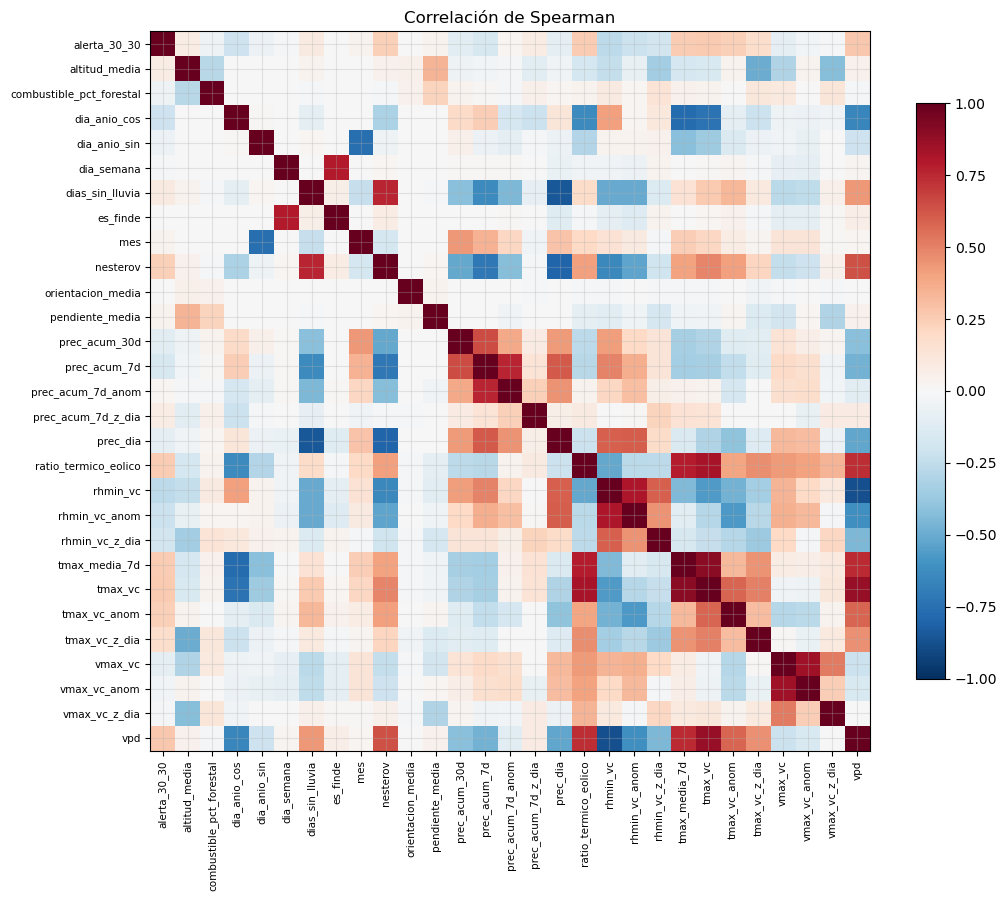

In [5]:
num = [c for c in candidatas if df[c].dtype.kind in "fiu"]
corr = va[num].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num))); ax.set_xticklabels(num, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(num))); ax.set_yticklabels(num, fontsize=7.5)
ax.set_title("Correlación de Spearman")
fig.colorbar(im, shrink=0.8)
plt.tight_layout()

alta = (corr.where(~np.eye(len(corr), dtype=bool)).abs().stack()
        .sort_values(ascending=False).drop_duplicates())
print("Pares con |rho| > 0.8 — candidatos a eliminar uno de los dos:")
print(alta[alta > 0.8].round(3).to_string())

---
## 4. Perfil físico del incendio

Distribución de cada variable en los días que ardieron frente a los que no. Sirve de
comprobación de cordura: si el VPD o los días sin lluvia no se separan, es que algo está mal
calculado, porque la física del fuego dice que deberían.

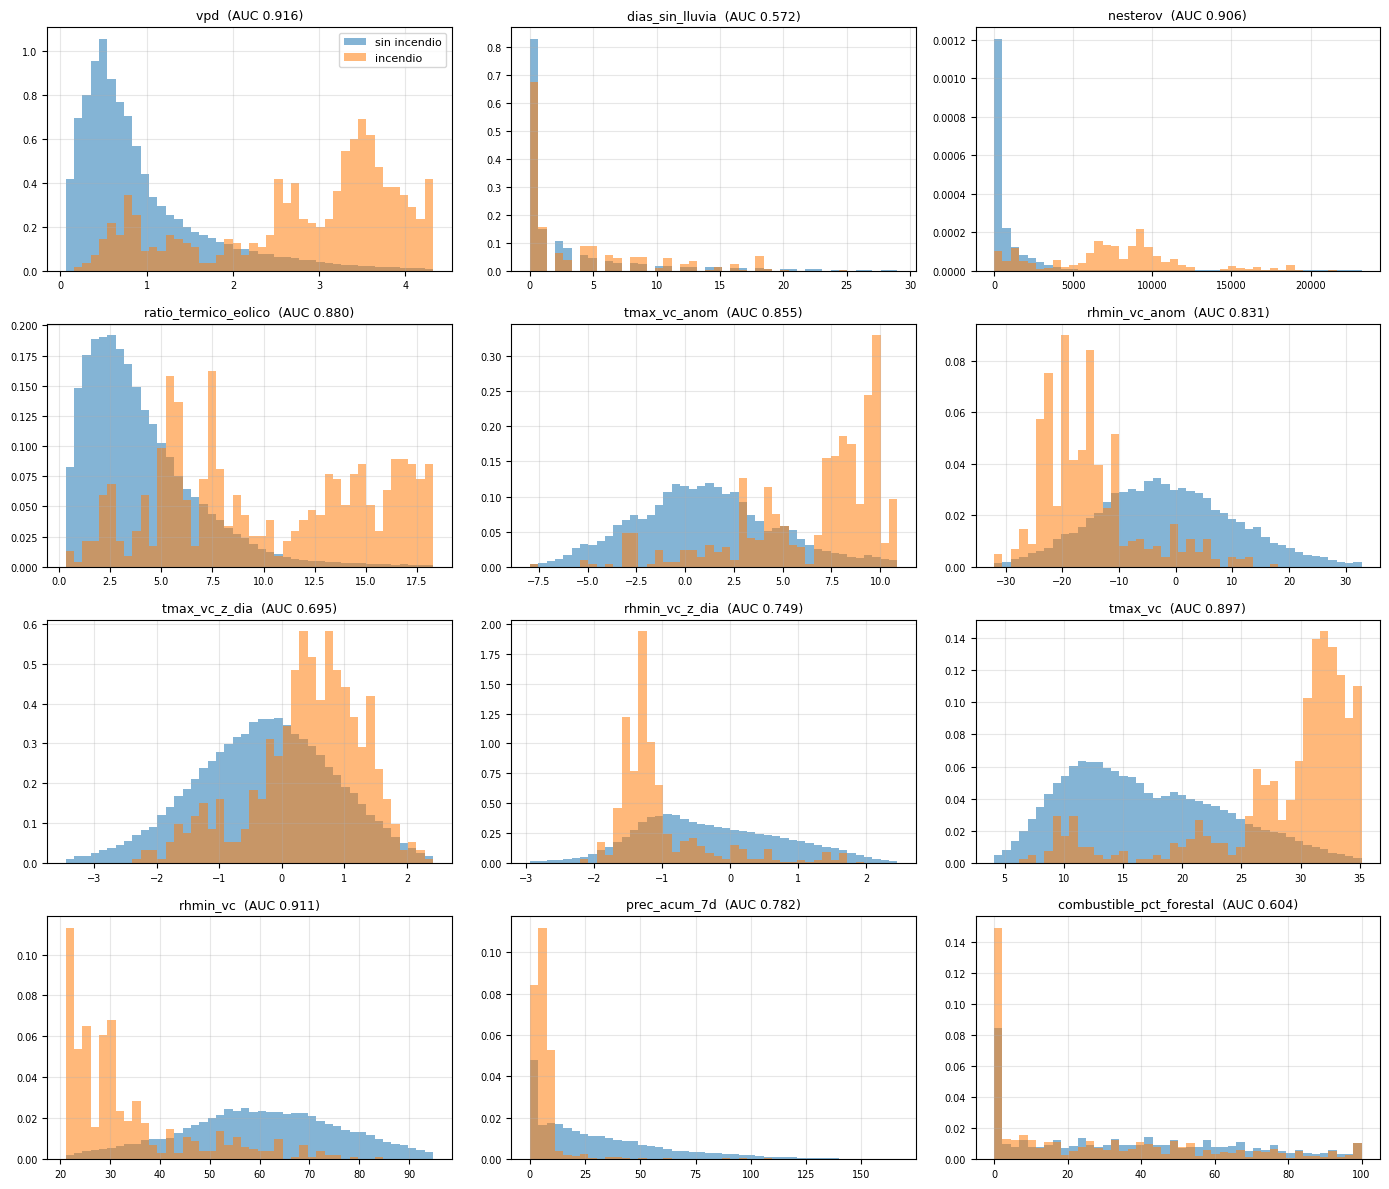

In [6]:
mostrar = ["vpd", "dias_sin_lluvia", "nesterov", "ratio_termico_eolico",
           "tmax_vc_anom", "rhmin_vc_anom", "tmax_vc_z_dia", "rhmin_vc_z_dia",
           "tmax_vc", "rhmin_vc", "prec_acum_7d", "combustible_pct_forestal"]

fig, axes = plt.subplots(4, 3, figsize=(14, 12))
for ax, c in zip(axes.ravel(), mostrar):
    a = va.loc[va.target == 0, c].dropna()
    b = va.loc[va.target == 1, c].dropna()
    lo, hi = np.nanpercentile(pd.concat([a, b]), [0.5, 99.5])
    bins = np.linspace(lo, hi, 45)
    ax.hist(a, bins=bins, density=True, alpha=0.55, label="sin incendio")
    ax.hist(b, bins=bins, density=True, alpha=0.55, label="incendio")
    ax.set_title(f"{c}  (AUC {max(roc_auc_score(va.target, va[c].fillna(0)), 1 - roc_auc_score(va.target, va[c].fillna(0))):.3f})",
                 fontsize=9)
    ax.tick_params(labelsize=7)
axes.ravel()[0].legend(fontsize=8)
plt.tight_layout()

---
## 5. ¿Dónde arde? Combustible y terreno

Las categóricas se descartaban en los experimentos anteriores del repositorio por ser cadenas
de texto. Aquí se mide cuánto aportan: el **lift** es cuántas veces más probable es el incendio
en esa clase respecto a la media de la muestra.

In [7]:
for col in ["combustible_clase", "orientacion_clase"]:
    t = (va.groupby(col, observed=True)
           .agg(n=("target", "size"), incendios=("target", "sum")))
    t["tasa"] = t.incendios / t.n
    t["lift"] = t.tasa / va.target.mean()
    print(f"\n=== {col} ===")
    print(t[t.n > 200].sort_values("lift", ascending=False).round(3).to_string())


=== combustible_clase ===
                       n  incendios   tasa   lift
combustible_clase                                
matorral           38965        453  0.012  1.759
pastizal            2877         28  0.010  1.473
urbano              1193         11  0.009  1.395
bosque_coniferas    8841         66  0.007  1.130
bosque_frondosas   26205         88  0.003  0.508
agua_humedal         761          2  0.003  0.398
bosque_mixto        2625          6  0.002  0.346
agricola           24514         49  0.002  0.302
sin_dato             408          0  0.000  0.000

=== orientacion_clase ===
                       n  incendios   tasa   lift
orientacion_clase                                
este               13865        107  0.008  1.168
oeste              18216        126  0.007  1.047
sur                73470        469  0.006  0.966
norte                838          1  0.001  0.181


---
## 6. Decisión: el juego de variables propuesto

Rellena esta celda con lo que digan los resultados de arriba, y compara el conjunto propuesto
contra el actual con el mismo protocolo. La comparación se hace **dentro del día**, que es el
criterio que nos importa.

In [8]:
ACTUAL = ["tmax_vc", "rhmin_vc", "vmax_vc", "prec_dia", "prec_acum_7d", "prec_acum_30d",
          "tmax_media_7d", "alerta_30_30", "altitud_media", "pendiente_media",
          "orientacion_media", "combustible_pct_forestal", "mes", "dia_semana",
          "es_finde", "dia_anio_sin", "dia_anio_cos"]

# Propuesta: se sustituyen las magnitudes absolutas por anomalias y posiciones relativas,
# se anaden los indices fisicos y se recorta la redundancia detectada en la seccion 3.
PROPUESTO = ["tmax_vc_anom", "rhmin_vc_anom", "vmax_vc_anom", "prec_acum_7d_anom",
             "tmax_vc_z_dia", "rhmin_vc_z_dia", "vmax_vc_z_dia", "prec_acum_7d_z_dia",
             "vpd", "dias_sin_lluvia", "nesterov", "ratio_termico_eolico",
             "vpd_x_forestal", "seq_x_forestal",
             "altitud_media", "pendiente_media", "orientacion_media",
             "combustible_pct_forestal", "dia_anio_sin", "dia_anio_cos"]

from lightgbm import LGBMClassifier

def compara(nombre, cols):
    m = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                       min_child_samples=100, subsample=0.8, subsample_freq=1,
                       colsample_bytree=0.8, reg_lambda=5.0,
                       random_state=42, n_jobs=-1, verbose=-1)
    m.fit(tr[cols].fillna(0), tr.target)
    p = m.predict_proba(va[cols].fillna(0))[:, 1]
    tmp = va[["fecha_real", "target"]].copy(); tmp["p"] = p
    intra, n_dias = auc_intra_dia("p", tmp)
    return {"conjunto": nombre, "n_vars": len(cols),
            "auc_global": roc_auc_score(va.target, p),
            "auc_intra_dia": intra, "n_dias": n_dias}

pd.DataFrame([compara("ACTUAL", ACTUAL), compara("PROPUESTO", PROPUESTO),
              compara("AMBOS", sorted(set(ACTUAL) | set(PROPUESTO)))]).round(4)

,conjunto,n_vars,auc_global,auc_intra_dia,n_dias
0,ACTUAL,17,0.8753,0.6505,74
1,PROPUESTO,20,0.8840,0.7161,74
2,AMBOS,31,0.8726,0.6987,74


---
## Qué hacer con la conclusión

Si `PROPUESTO` mejora el **AUC dentro del día**, el siguiente paso es llevar estas variables al
pipeline de verdad, no quedarse en el cuaderno:

1. Conectar `src/features/derived.py` a `src/models/dataset.py`, de modo que las derivadas se
   calculen también en el recorrido por bloques del entrenamiento real.
2. Añadir la lista definitiva a `configs/model_v1.yaml`.
3. Relanzar `python -m scripts.train_model --models lightgbm xgboost logistic_regression` y
   comparar contra los resultados guardados en `docs/technical/model_v1_fixed_resultados.csv`.
4. Registrar la decisión y su justificación en `MODEL_DOCUMENTATION.md` §3.

Recordatorio metodológico: los números de este cuaderno salen de una muestra 1:150 y del **año
de validación**. Sirven para elegir variables. El rendimiento real solo lo dice el pipeline
completo sobre el año entero, y el test ciego (2023-2024) sigue sin tocarse.